# Numerisk dobbeltintegrasjon med triangulering: Delaunay

Denne notebooken er en oppfølging til **Øving 1, oppgave 17**, der dere deler opp integrasjonsområdet i noen få, håndplukkede trekanter og summerer $f\cdot dA$ over dem. Her repeterer vi kort den ideen, og bygger den så videre ut: `scipy.spatial.Delaunay` kan lage trianguleringen automatisk fra en liste med punkter, slik at vi enkelt kan bruke mange flere trekanter og få en mye bedre tilnærming.

## Repetisjon: å integrere ved å summere over trekanter

Vi vil tilnærme
$$\iint_D f(x,y)\, dA$$
ved å dele $D$ opp i $N$ trekanter med hjørner $p_i,q_i,r_i$, og bruke at
$$\iint_D f\, dA \approx \sum_{i=1}^N f(x_i,y_i)\, dA_i,$$
der $(x_i,y_i)=\tfrac13(p_i+q_i+r_i)$ er tyngdepunktet til trekant $i$, og arealet er
$$dA_i = \tfrac12\,\bigl|\det(u_i\ v_i)\bigr|, \qquad u_i = q_i-p_i,\ \ v_i = r_i-p_i.$$

### Eksempel med håndplukkede trekanter

Som i oppgave 17 lager vi en liste med punkter `pts`, og en liste `triangles` som sier hvilke tre punkter (indekser i `pts`) som utgjør hjørnene i hver trekant. Her deler vi rektangelet $[0,2]\times[0,1]$ opp i $4$ trekanter, og integrerer $f(x,y)=x^2+y$ over det. Vi visualiserer også hvor tyngdepunktene til trekantene ligger -- det er der vi evaluerer $f$.

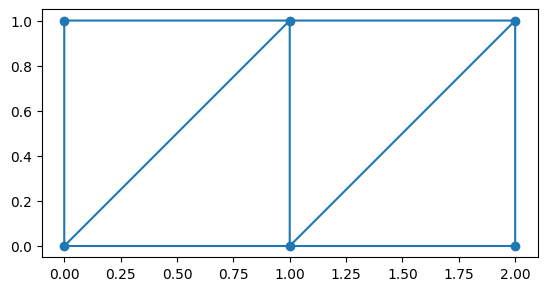

In [1]:
%matplotlib inline
from matplotlib import pyplot as plt
import numpy as np

pts = np.array([[0,0],[1,0],[2,0],[0,1],[1,1],[2,1]])        # liste med punkter (x,y) i planet
triangles = np.array([[0,1,4],[0,4,3],[1,2,5],[1,5,4]])      # hvilke punkter i pts (indekser) som danner hver trekant

plt.triplot(pts[:,0], pts[:,1], triangles)   # tegner selve trekantene
plt.scatter(pts[:,0], pts[:,1])              # tegner punktene som små markører
plt.gca().set_aspect('equal')                # samme skala på x- og y-aksen, så trekantene ser riktige ut
plt.show()

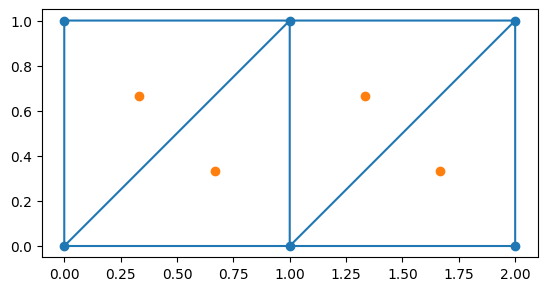

Tilnærmet svar: 3.5555555555555554
Tyngdepunkter:
 [[0.66666667 0.33333333]
 [0.33333333 0.66666667]
 [1.66666667 0.33333333]
 [1.33333333 0.66666667]]
Trekant-arealer: [0.5 0.5 0.5 0.5]


In [2]:
p = pts[triangles[:,0]]   # array med første hjørne i hver trekant
q = pts[triangles[:,1]]   # array med andre hjørne i hver trekant
r = pts[triangles[:,2]]   # array med tredje hjørne i hver trekant
n = len(p)                # antall trekanter -- trengs når vi skal reshape senere

avg = 1/3 * (p + q + r)   # tyngdepunktet (massesenteret) til hver trekant
x = avg[:,0]
y = avg[:,1]
f = x**2 + y              # funksjonen f, evaluert i tyngdepunktene

# Plotting: trekantene, hjørnepunktene, og tyngdepunktene der vi evaluerer f
plt.triplot(pts[:,0], pts[:,1], triangles)   # tegner trekantene
plt.scatter(pts[:,0], pts[:,1])              # tegner hjørnepunktene
plt.scatter(x, y)                            # tegner tyngdepunktene
plt.gca().set_aspect('equal')
plt.show()

# Vektorer som spenner ut hver trekant, med utgangspunkt i hjørnet p
u = q - p
v = r - p

# Setter sammen u og v som kolonner i en 2x2-matrise, én per trekant
Muv = np.column_stack((u, v)).reshape(n, 2, 2)   # (n,2,2) -- en array av 2x2-matriser
dA = np.abs(1/2 * np.linalg.det(Muv))            # arealet til hver trekant, via determinanten

svar = np.sum(dA * f)   # summerer f(tyngdepunkt) * dA over alle trekantene
print("Tilnærmet svar:", svar)
print("Tyngdepunkter:\n", avg)
print("Trekant-arealer:", dA)

## Automatisk triangulering med `scipy.spatial.Delaunay`

Å plukke ut trekanter for hånd blir fort tungvint når vi ønsker mange trekanter (for bedre nøyaktighet). `Delaunay` tar rett og slett inn en liste med punkter, og finner selv en fornuftig triangulering av dem -- helt analogt til `triangles`-arrayet vi lagde for hånd over.

[[1 4 0]
 [4 3 0]
 [5 4 2]
 [4 1 2]]


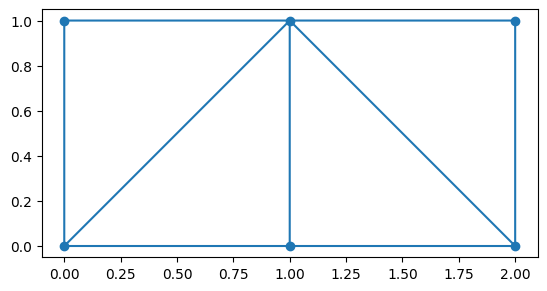

In [3]:
from scipy.spatial import Delaunay

tri = Delaunay(pts)     # samme punkter som over, men nå lar vi Delaunay velge trekantene selv

print(tri.simplices)    # samme type array som "triangles" vi definerte for hånd

plt.triplot(pts[:,0], pts[:,1], tri.simplices)   # tegner Delaunay sin triangulering
plt.scatter(pts[:,0], pts[:,1])                  # tegner punktene
plt.gca().set_aspect('equal')
plt.show()

`tri.simplices` er nøyaktig samme type array som `triangles`-arrayet vi selv definerte: en liste med indekser inn i `pts`, tre og tre, én rad per trekant (Delaunay kan velge en annen diagonal enn oss, men trekantene dekker fortsatt hele området). Vi kan derfor gjenbruke akkurat samme utregning som over -- vi pakker den inn i en funksjon, så slipper vi å skrive den på nytt hver gang:

In [4]:
def trekant_integrasjon(pts, triangles, f):
    p = pts[triangles[:,0]]        # første hjørne i hver trekant
    q = pts[triangles[:,1]]        # andre hjørne i hver trekant
    r = pts[triangles[:,2]]        # tredje hjørne i hver trekant
    n = len(p)                     # antall trekanter

    avg = 1/3 * (p + q + r)        # tyngdepunktet i hver trekant
    x = avg[:,0]
    y = avg[:,1]
    fverdier = f(x, y)             # funksjonsverdien i hvert tyngdepunkt

    u = q - p                      # vektorer som spenner ut trekanten
    v = r - p
    Muv = np.column_stack((u, v)).reshape(n, 2, 2)   # 2x2-matrise per trekant
    dA = np.abs(1/2 * np.linalg.det(Muv))            # areal av hver trekant

    return np.sum(dA * fverdier)   # summen tilnærmer integralet

def f(x, y):
    return x**2 + y

print("Delaunay med samme punkter:", trekant_integrasjon(pts, tri.simplices, f))

Delaunay med samme punkter: 3.5555555555555554


## Mange punkter -> mange trekanter -> bedre tilnærming

Nå kan vi lage et fint rutenett av punkter -- akkurat som vi har gjort med `np.linspace` og `np.meshgrid` tidligere -- og la `Delaunay` triangulere det for oss. Med mange trekanter forventer vi et resultat nær det eksakte svaret.

For $f(x,y)=x^2+y$ over $[0,2]\times[0,1]$ er det eksakte integralet
$$\int_0^2\!\int_0^1 (x^2+y)\, dy\, dx = \frac{11}{3} \approx 3.6667.$$

In [5]:
nx, ny = 60, 30
xvals = np.linspace(0, 2, nx)          # x-verdier over [0,2]
yvals = np.linspace(0, 1, ny)          # y-verdier over [0,1]
X, Y = np.meshgrid(xvals, yvals)       # rutenett av (x,y)-par

pts_fin = np.column_stack((X.ravel(), Y.ravel()))   # (nx*ny, 2) -- alle rutenett-punktene som (x,y)-par
tri_fin = Delaunay(pts_fin)                          # trianguler hele rutenettet automatisk

svar_fin = trekant_integrasjon(pts_fin, tri_fin.simplices, f)

print("Antall trekanter:", len(tri_fin.simplices))
print("Tilnærmet svar:", svar_fin)
print("Eksakt svar (11/3):", 11/3)

Antall trekanter: 3422
Tilnærmet svar: 3.666538989434709
Eksakt svar (11/3): 3.6666666666666665


### Oppgave (løses i forelesningen)

Bruk samme fremgangsmåte (rutenett med `np.linspace`/`np.meshgrid` + `Delaunay` + `trekant_integrasjon`) til å regne ut
$$\int_0^1\int_0^2 xy\, dy\, dx.$$

In [6]:
# Skriv koden her

## Alternativ: tilfeldige punkter med ekstra punkter på randen

Et rutenett er ikke den eneste måten å lage mange punkter på. Vi kan like gjerne bruke tilfeldige punkter -- akkurat som i Monte Carlo-notebooken. Det er likevel én ting vi må passe på: `Delaunay` triangulerer bare det konvekse hylsteret til punktene vi gir den, så strør vi ut rent tilfeldige punkter, er det ikke sikkert vi treffer helt ut i hjørnene og langs kantene av rektangelet -- trianguleringen kan da bli litt "avrundet" i kantene. Løsningen er å legge til noen punkter eksplisitt langs randen (og i hjørnene), i tillegg til de tilfeldige punktene i det indre.

Totalt antall punkter: 364


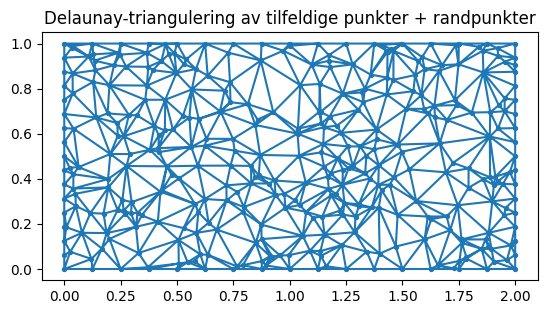

Antall trekanter: 662
Tilnærmet svar: 3.6653638751260433
Eksakt svar (11/3): 3.6666666666666665


In [7]:
np.random.seed(0)   # gjør at vi får de samme "tilfeldige" punktene hver gang vi kjører cellen

xmin, xmax = 0.0, 2.0   # samme rektangel som over: [0,2] x [0,1]
ymin, ymax = 0.0, 1.0

n_indre = 300   # antall tilfeldige punkter i det indre av rektangelet

# Tilfeldige punkter jevnt fordelt i rektangelet (samme idé som i Monte Carlo-notebooken)
indre_x = np.random.rand(n_indre) * (xmax - xmin) + xmin
indre_y = np.random.rand(n_indre) * (ymax - ymin) + ymin
indre = np.column_stack((indre_x, indre_y))   # (n_indre, 2) -- de indre punktene som (x,y)-par

# De fire hjørnene, lagt til eksplisitt slik at trianguleringen dekker HELE rektangelet
hjorner = np.array([
    [xmin, ymin],   # nede til venstre
    [xmax, ymin],   # nede til høyre
    [xmin, ymax],   # oppe til venstre
    [xmax, ymax],   # oppe til høyre
])

n_rand = 15   # antall ekstra punkter langs HVER av de fire kantene

# Punkter jevnt fordelt langs hver kant (hjørnene er allerede med, så de kuttes bort med [1:-1])
bunn    = np.column_stack((np.linspace(xmin, xmax, n_rand+2)[1:-1], np.full(n_rand, ymin)))   # y = ymin
topp    = np.column_stack((np.linspace(xmin, xmax, n_rand+2)[1:-1], np.full(n_rand, ymax)))   # y = ymax
venstre = np.column_stack((np.full(n_rand, xmin), np.linspace(ymin, ymax, n_rand+2)[1:-1]))   # x = xmin
hoyre   = np.column_stack((np.full(n_rand, xmax), np.linspace(ymin, ymax, n_rand+2)[1:-1]))   # x = xmax

# Setter sammen alt til én liste med punkter: indre (tilfeldige) + hjørner + randpunkter
pts_rand = np.vstack((indre, hjorner, bunn, topp, venstre, hoyre))
print("Totalt antall punkter:", len(pts_rand))

tri_rand = Delaunay(pts_rand)   # trianguler alle punktene

plt.triplot(pts_rand[:,0], pts_rand[:,1], tri_rand.simplices)
plt.scatter(pts_rand[:,0], pts_rand[:,1], s=8)   # s=8: litt mindre markører, siden vi har mange punkter
plt.gca().set_aspect('equal')
plt.title("Delaunay-triangulering av tilfeldige punkter + randpunkter")
plt.show()

svar_rand = trekant_integrasjon(pts_rand, tri_rand.simplices, f)   # samme funksjon som før

print("Antall trekanter:", len(tri_rand.simplices))
print("Tilnærmet svar:", svar_rand)
print("Eksakt svar (11/3):", 11/3)

Legg merke til at dette gir en tilnærming på samme nivå som rutenett-metoden over, bare med tilfeldig plasserte punkter i stedet for et jevnt rutenett -- randpunktene sørger for at vi likevel dekker hele rektangelet skikkelig.

### Oppgave (løses i forelesningen)

Bruk samme fremgangsmåte (tilfeldige indre punkter + randpunkter + `Delaunay` + `trekant_integrasjon`) til å regne ut
$$\int_0^\pi\int_0^1 \bigl(\sin(x)+y\bigr)\, dy\, dx.$$

In [8]:
# Skriv koden her

## Oppsummering

1. Vi tilnærmer $\iint_D f\, dA$ ved å summere $f(\text{tyngdepunkt})\cdot dA$ over trekanter som dekker $D$.
2. Trekantene kan lages for hånd (praktisk for et lite eksempel), eller automatisk med `scipy.spatial.Delaunay` gitt en liste med punkter.
3. `tri.simplices` fungerer akkurat som vår håndlagde `triangles`-array, så samme formel gjenbrukes uendret.
4. Flere punkter gir flere, mindre trekanter -- og dermed en bedre tilnærming til det eksakte integralet.

Nå har dere det dere trenger for å fullføre den siste delen av oppgave 17 i Øving 1.